Paso 1: Cargar los datos

In [3]:
# Usamos la misma estructura del codigo caso 1 para cargar el Dataset
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import io

print("Seleccione el archivo CSV desde su computador:")
upload = widgets.FileUpload(accept='.csv', multiple=False)
display(upload)

def load_dataset(change):
    
    # En ipywidgets v8+, change['new'] contiene la lista de archivos
    if not change['new']:
        return
    
    # Correctly access the file information when multiple=False
    # upload.value is a dictionary, so we get the first (and only) item's value
    file_info = change['new'][0]
    content = file_info['content']

    global df
    df = pd.read_csv(io.BytesIO(content), sep=',')

    print("\nDataset cargado correctamente\n")
    display(df.head())

upload.observe(load_dataset, names='value')

Seleccione el archivo CSV desde su computador:


FileUpload(value=(), accept='.csv', description='Upload')

,Serial No,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


Paso 2: Exploracion Visual de variables

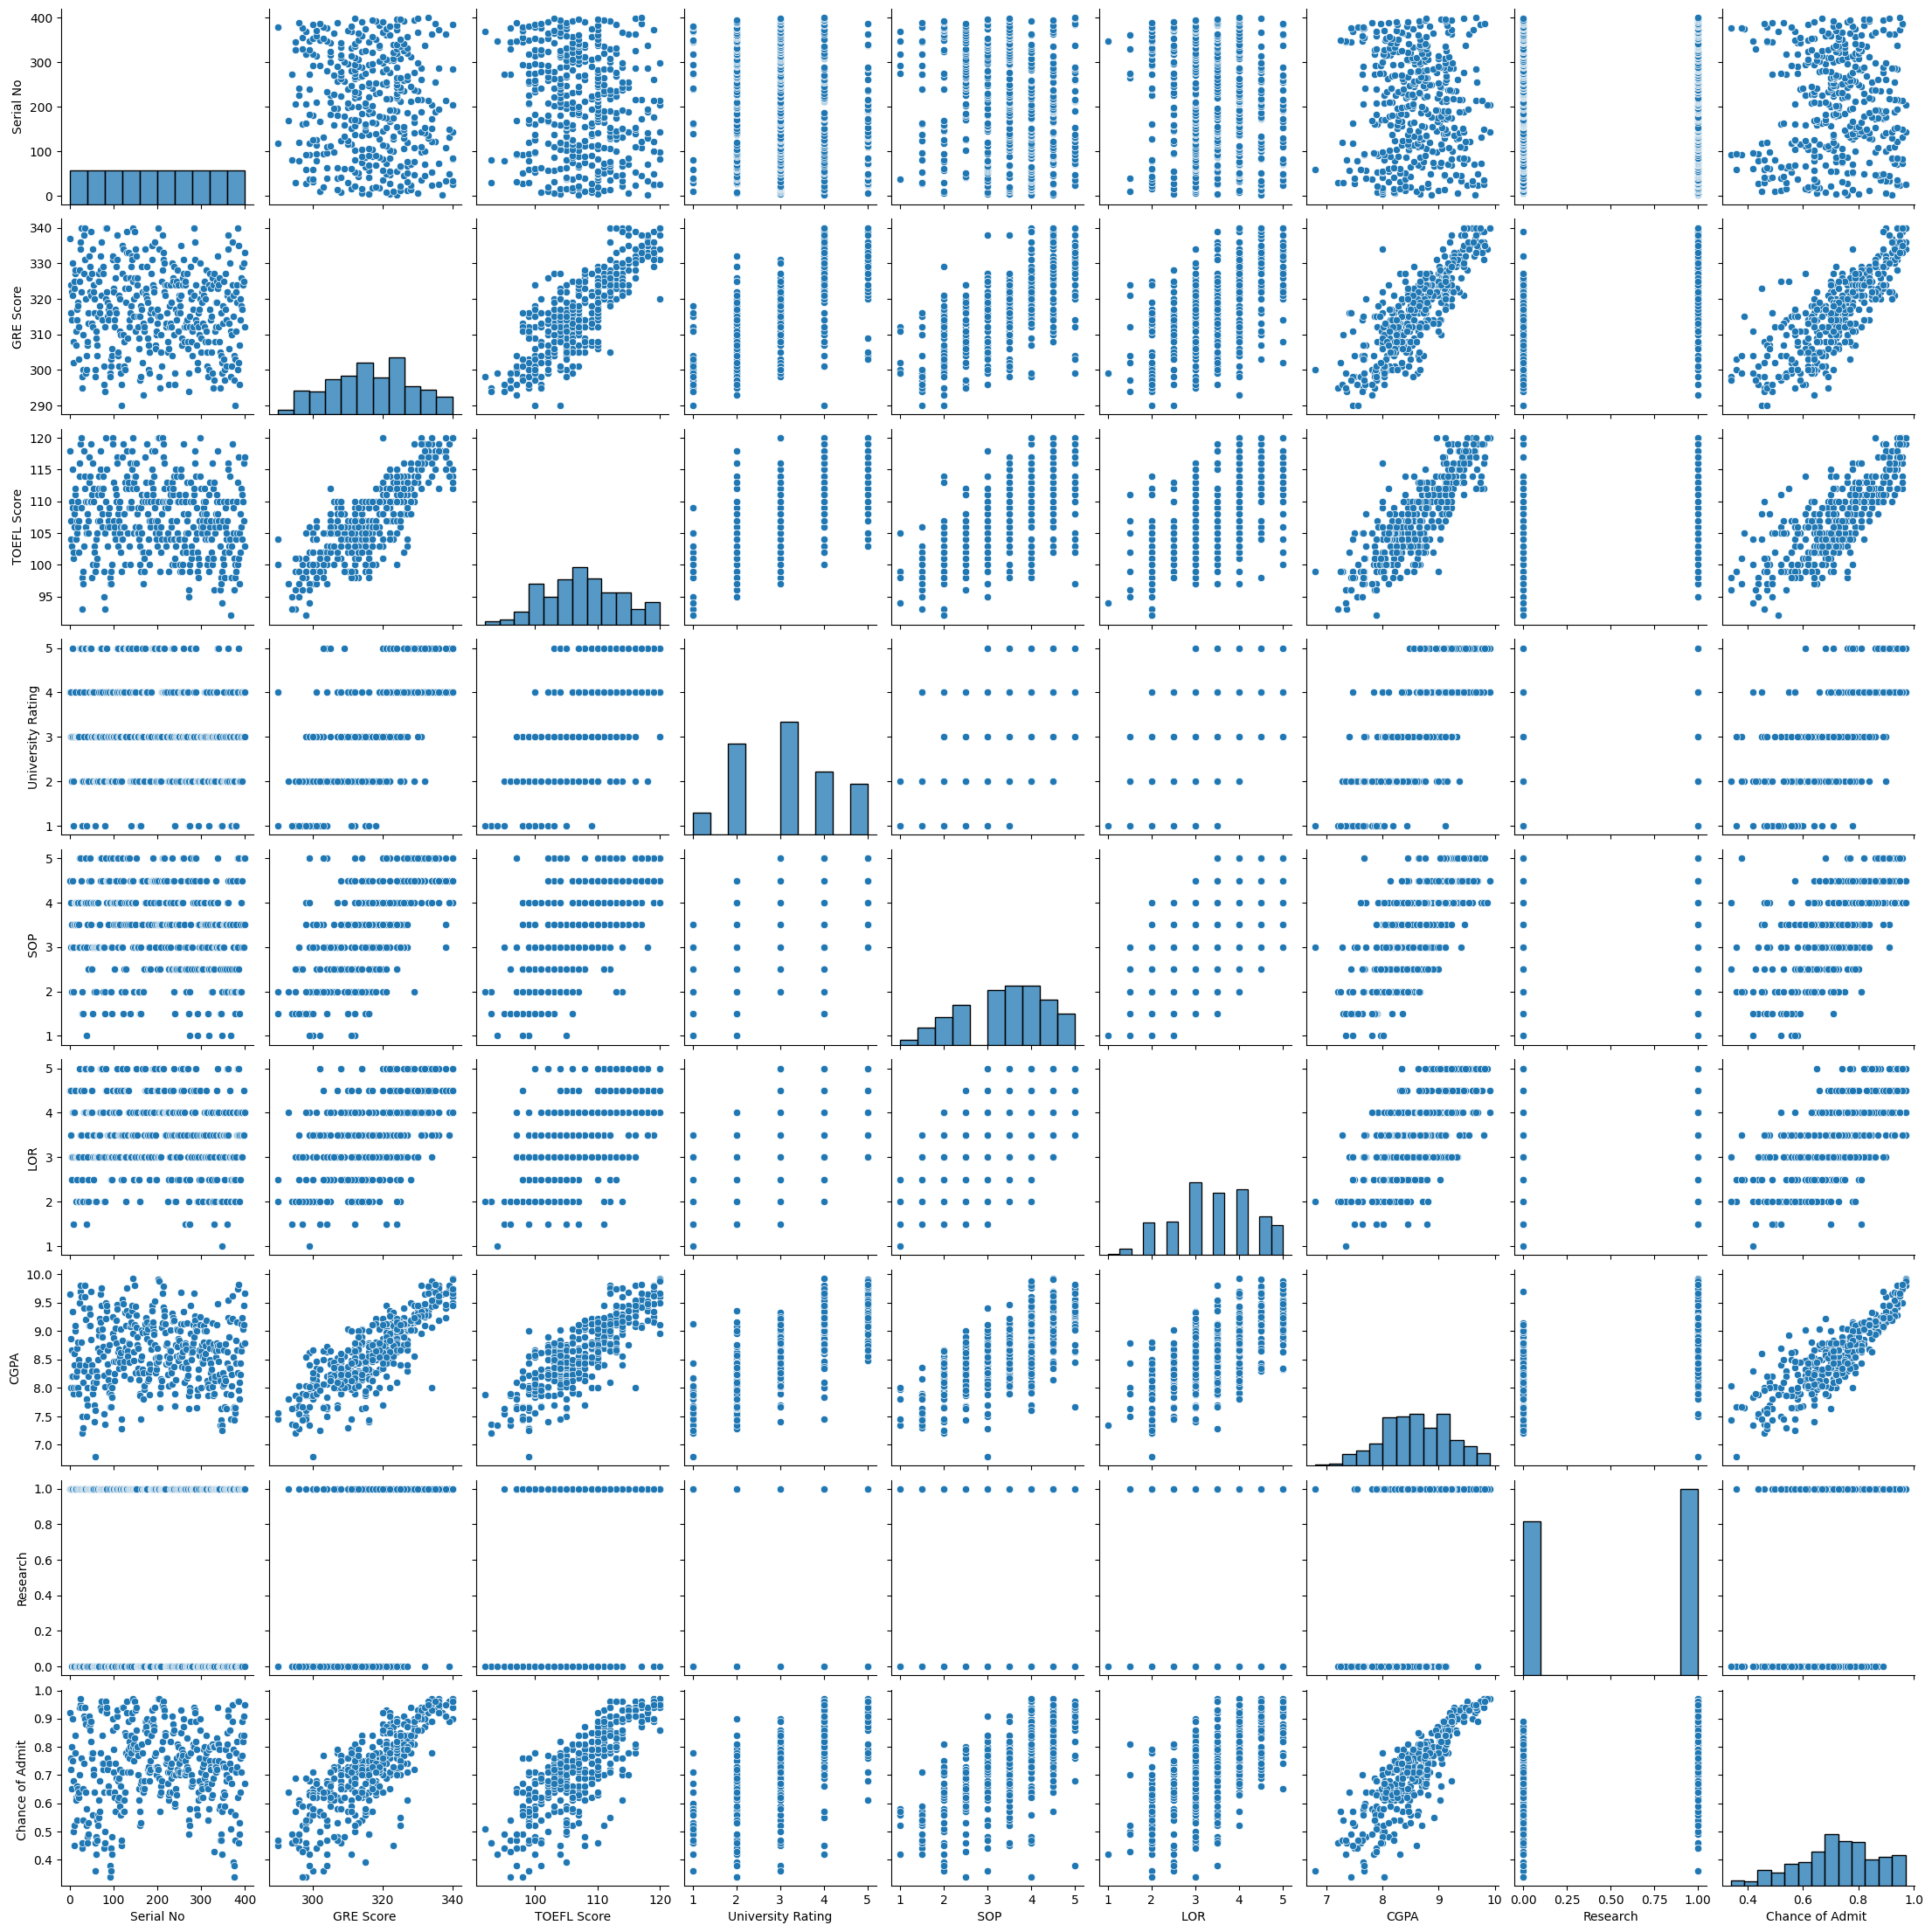

In [4]:
import seaborn as sns
sns.pairplot(df)

Paso 3: Entrenamiento del Modelo

In [5]:
# Definir la variable objetivo (target)
# Esta es la variable que queremos predecir: la probabilidad de admisión
y = df['Chance of Admit ']

# Definir las variables predictoras (features)
# Se eliminan:
# - 'Serial No' porque es solo un identificador y no aporta información al modelo
# - 'Chance of Admit ' porque es la variable objetivo
X = df.drop(['Serial No', 'Chance of Admit '], axis=1)

Paso 3.1: Division de datos en Train and Test

In [6]:
# Dividir los datos en conjuntos de entrenamiento y prueba
from sklearn.model_selection import train_test_split

# X: variables predictoras
# y: variable objetivo

# Se divide el dataset en:
# - 80% para entrenamiento (train)
# - 20% para prueba (test)
# random_state garantiza que la división sea reproducible

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.8,
    random_state=2529
)

In [7]:
# Importar el modelo de árbol de decisión para regresión y la función para visualizar el árbol
from sklearn.tree import DecisionTreeRegressor, plot_tree

# Crear el modelo de árbol de decisión
# max_depth=6 especifica la profundidad del árbol
# random_state=2529 asegura que los resultados sean reproducibles
dtr = DecisionTreeRegressor(max_depth=6, random_state=2529) ##Notese que aqui se selecciona el modelo a utilizar, en este caso arboles de decision. sin embargo se podria seleccionar cualqueir modelo de sklearn, incluyendo regresion lineal multiple vista en el caso 1. (se recomienda que el estudiante explore los modelos de regresion contenidos en https://scikit-learn.org/stable/supervised_learning.html)

Validacion cruzada (Cross-Validation)

In [8]:
# Validar el modelo utilizando validación cruzada (cross-validation)
from sklearn.model_selection import cross_validate

# Se evalúa el modelo dtr utilizando únicamente los datos de entrenamiento
# cv=5 indica que se realizará una validación cruzada con 5 particiones (folds)
# El modelo se entrena y valida 5 veces con diferentes subconjuntos de los datos
# Esto permite obtener una estimación más robusta del desempeño del modelo

cross_validate(dtr, X_train, y_train, cv=5)

{'fit_time': array([0.00881696, 0.00645113, 0.00436115, 0.00321388, 0.00665069]),
 'score_time': array([0.00314808, 0.00332403, 0.00164676, 0.00316548, 0.00604987]),
 'test_score': array([0.42259632, 0.59354562, 0.45977752, 0.77411881, 0.66810442])}

Ajuste de hiperparametros Grid Search

In [9]:
# Mostrar los hiperparámetros actuales del modelo de árbol de decisión
# Esto permite conocer la configuración inicial del modelo antes de optimizarlo
dtr.get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': 6,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 2529,
 'splitter': 'best'}

In [10]:
# Definir las combinaciones de hiperparámetros que se desean evaluar
# model__ indica que estos parámetros pertenecen al modelo dentro del Pipeline

params = {
    'model__max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10],   # Profundidad máxima del árbol
    'model__criterion': ['squared_error', 'absolute_error'],  # Función de error para dividir nodos
    'model__random_state': [2529]   # Semilla para asegurar reproducibilidad
}

In [11]:
# Importar la clase Pipeline
# Pipeline permite organizar el flujo de trabajo del modelo dentro de una sola estructura
from sklearn.pipeline import Pipeline

In [12]:
# Definir un pipeline que contiene el modelo de árbol de decisión
# En este caso solo se incluye un paso llamado 'model'
pipe = Pipeline([('model', dtr)])

In [13]:
# Importar GridSearchCV
# Esta herramienta prueba múltiples combinaciones de hiperparámetros
# y selecciona la mejor utilizando validación cruzada
from sklearn.model_selection import GridSearchCV

# Crear el objeto GridSearchCV
# cv=5 indica que se usará validación cruzada con 5 particiones
grid = GridSearchCV(pipe, params, cv=5)

In [14]:
# Mostrar la configuración del Grid Search
# Esto permite verificar el estimador, el pipeline y la grilla de parámetros
grid

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=2529))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['squared_error', 'absolute_error'], 'model__max_depth': [2, 3, ...], 'model__random_state': [2529]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [15]:
# Entrenar GridSearchCV con los datos de entrenamiento
# El algoritmo probará todas las combinaciones de hiperparámetros definidas
# y evaluará cada una utilizando validación cruzada
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...state=2529))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__criterion': ['squared_error', 'absolute_error'], 'model__max_depth': [2, 3, ...], 'model__random_state': [2529]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter

In [16]:
# Mostrar la mejor combinación de hiperparámetros encontrada
# según el desempeño obtenido durante la validación cruzada
grid.best_params_

{'model__criterion': 'squared_error',
 'model__max_depth': 3,
 'model__random_state': 2529}

Modelo óptimo entrenado
R² en entrenamiento: 0.7738

Evaluación en conjunto de prueba
--------------------------------
MAE  (Error absoluto medio): 0.0572
MAPE (Error porcentual medio): 0.0972
R²   (Coeficiente de determinación): 0.7533


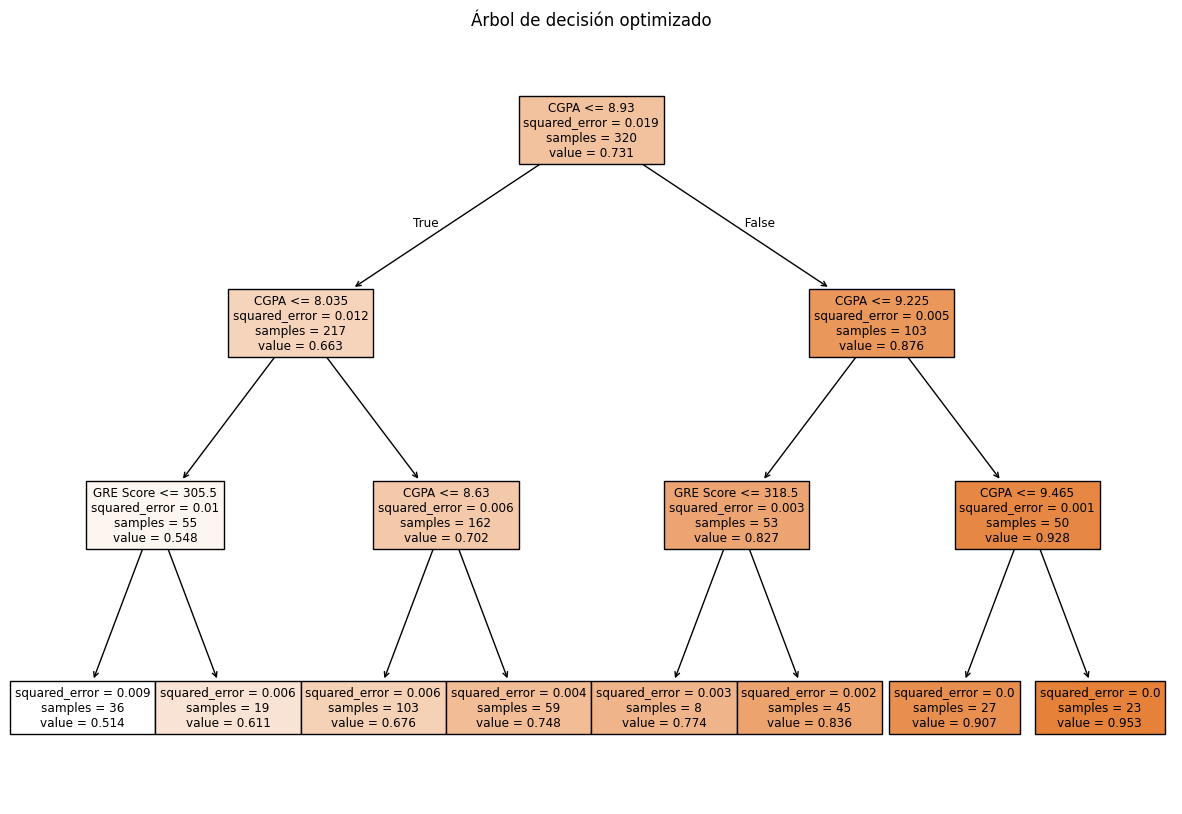

In [17]:
# ================================
# 1. Seleccionar mejor modelo
# ================================
best = grid.best_estimator_

# ================================
# 2. Entrenar mejor modelo
# ================================
best.fit(X_train, y_train)

print("Modelo óptimo entrenado")

# ================================
# 3. Evaluación en entrenamiento
# ================================
train_score = best.score(X_train, y_train)
print(f"R² en entrenamiento: {train_score:.4f}")

# ================================
# 4. Predicciones en test
# ================================
y_pred = best.predict(X_test)

# ================================
# 5. Métricas de evaluación
# ================================
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nEvaluación en conjunto de prueba")
print("--------------------------------")
print(f"MAE  (Error absoluto medio): {mae:.4f}")
print(f"MAPE (Error porcentual medio): {mape:.4f}")
print(f"R²   (Coeficiente de determinación): {r2:.4f}")

# ================================
# 6. Visualización del árbol
# ================================
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, DecisionTreeRegressor

# Crear modelo final (mismos hiperparámetros óptimos)
final = DecisionTreeRegressor(max_depth=3, random_state=2529)
final.fit(X_train, y_train)

# Graficar árbol
fig, ax = plt.subplots(figsize=(15, 10))
plot_tree(final, feature_names=X.columns, filled=True)

plt.title("Árbol de decisión optimizado")
plt.show()

In [18]:
# Mostrar la mejor combinación de hiperparámetros encontrada
# según el desempeño obtenido durante la validación cruzada
grid.best_params_

{'model__criterion': 'squared_error',
 'model__max_depth': 3,
 'model__random_state': 2529}